# Starting tests to model 2025wny

## Drive setup and imports

In [1]:
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/repos/GL-PS
%ls

Mounted at /content/drive
/content/drive/MyDrive/repos/GL-PS
modeling/  notebooks/  README.md  src/  test.txt


In [3]:
!nvidia-smi

#import gigalens
!pip install corner
!pip install lenstronomy==1.13.2
!pip install gigalens --no-deps

Thu Jan 22 21:49:48 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   31C    P0             44W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [6]:
import sys
# import modeling functions
from importlib import reload
import src.flux_ratios_pipeline_funcs
reload(src.flux_ratios_pipeline_funcs)
from src.flux_ratios_pipeline_funcs import *

# import gigalens functions
from gigalens.tf.inference import ModellingSequence
from gigalens.tf.model import ForwardProbModel, BackwardProbModel
from gigalens.model import PhysicalModel
from gigalens.tf.simulator import LensSimulator
from gigalens.simulator import SimulatorConfig
from gigalens.tf.profiles.light import sersic
from gigalens.tf.profiles.mass import sis, shear, epl, sie
from tensorflow_probability import distributions as tfd, bijectors as tfb

flux_ratios_pipeline_funcs.py version: 0.1.0
flux_ratios_pipeline_funcs.py version: 0.1.0


In [60]:
import os
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredDirectionArrows
from mpl_toolkits.axes_grid1 import make_axes_locatable
import pandas as pd
from astropy.io import fits
from astropy.wcs import WCS
from astropy.visualization import simple_norm
from astropy.visualization.wcsaxes import add_scalebar
from astropy.stats import sigma_clipped_stats



## Observational data



In [16]:

data_dir = '/content/drive/MyDrive/repos/GL-PS/modeling/2025wny/data/'
psfr_path = 'nirc2_psf_psfr_stacked.npy'
psf_path = 'nirc2_psf_stacked.npy'
image_fits = 'nirc2_wny_full.fits'
image_fits_clean = 'nirc2_wny_full_clean.fits'
psf_photutil_path = 'wny_photutil_psf_fit.csv'

with fits.open(data_dir + image_fits) as hdul:
  heads = hdul[0].header
  data = hdul[0].data
  hdul.close()

  heads_clean = hdul[0].header
  heads_list = ['CD1_1', 'CD1_2', 'CD2_1', 'CD2_2']
  for hl in heads_list:
    heads_clean[hl] = float(heads[hl])
  heads_clean['RADESYSa'] = heads['RADECSYS']
wcs = WCS(heads_clean)

psfr = np.load(data_dir + psfr_path)
psf = np.load(data_dir + psf_path)
psf_photutil = pd.read_csv(data_dir + psf_photutil_path)


the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]
the RADECSYS keyword is deprecated, use RADESYSa.
Set MJD-BEG to 60990.630833 from DATE-BEG.
Set MJD-END to 60990.632953 from DATE-END'. [astropy.wcs.wcs]
Set MJD-BEG to 60990.630833 from DATE-BEG.
Set MJD-END to 60990.632953 from DATE-END'.


In [28]:
psf_photutil

,Unnamed: 0,x_fit,y_fit,flux_fit,x_err,y_err,flux_err
0,0,491.346959,624.391736,60.829975,0.041131,0.045180,0.686246
1,1,433.149259,411.246418,17.631145,0.085960,0.094008,0.412534
2,2,634.350728,333.624255,14.024787,0.118965,0.131048,0.457709
3,3,884.289485,600.654906,8.869229,0.156156,0.172022,0.379112


In [72]:
data.shape

(1024, 1024)

SKy mean: -8.89e-02, sky median: -8.90e-02, sky std: 3.72e-02
-0.08740154


/tmp/ipython-input-1535754079.py:21: UserWarning: Adding colorbar to a different Figure <Figure size 800x800 with 2 Axes> than <Figure size 1000x500 with 2 Axes> which fig.colorbar is called on.
  plt.colorbar(im, ax = ax[0])


Text(0.5, 1.0, 'psf')

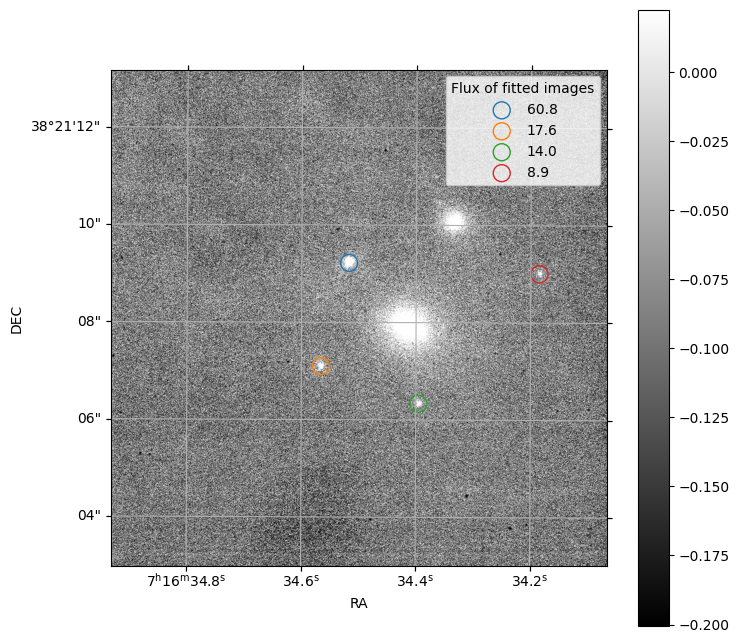

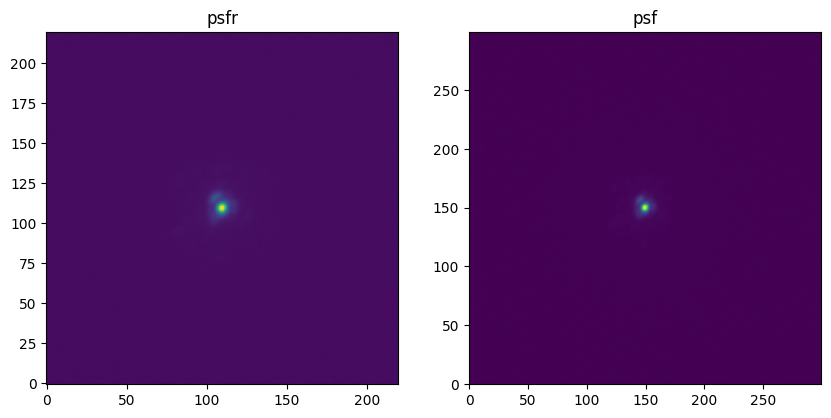

In [74]:

pixscale = 0.009952 # arcsec/px
exptime = 180

sky_mean, sky_median, sky_std = sigma_clipped_stats(data, sigma=2.0, maxiters=5)
print('SKy mean: %.2e, sky median: %.2e, sky std: %.2e'%(sky_mean, sky_median, sky_std))
print(np.mean(data))
stretch = 'linear'
percent = (5,99)
vminmax = (sky_mean - 3*sky_std,sky_mean + 3*sky_std)
# norm
norm = simple_norm(data, stretch,
                   #min_percent=percent[0], max_percent=percent[1],
                   vmin = vminmax[0], vmax = vminmax[1])
# figure
fig, ax = plt.subplots(1,1, figsize=(8,8))
fog, ax2 = plt.subplots(1,2, figsize=(10,5))
ax = [ax, ax2[0], ax2[1]]
ax[0].remove()
ax[0] = fig.add_subplot(1,1,1,projection=wcs)
im = ax[0].imshow(data, cmap='gray', origin = 'lower', norm = norm)
plt.colorbar(im, ax = ax[0])
for i in range(len(psf_photutil)):
  phot_row = psf_photutil.iloc[i]
  ax[0].scatter(phot_row['x_fit'], phot_row['y_fit'], label = '%.1f'%phot_row['flux_fit'],
             marker = 'o', s  = 150,
             facecolor = 'none', edgecolors=plt.get_cmap('tab10')(i), alpha = 1)
ax[0].legend(title = 'Flux of fitted images')
ax[0].set_xlabel('RA')
ax[0].set_ylabel('DEC')
ax[0].grid()

ax[1].imshow(psfr, origin = 'lower')
ax[1].set_title('psfr')

ax[2].imshow(psf, origin = 'lower')
ax[2].set_title('psf')

Keep going!! Start with code from notebook!!